# Univariate LSTM model with full input (no PCA)

**Directly predict *near-term* volatility (only) from historical return and volatility.**

Author: Pete King

This notebook uses financial data to train a univariate Long Short-Term Memory (LSTM) model to predict ***near-term*** **volatility** for a single ETF representing a market sector, using only the ETF's historical return and volatility as input.

The purpose of this notebook is to establish a baseline for an LSTM's ability to predict future volatility in a near-term outlook using limited input.  Subsequent LSTM models will incorporate additional features derived from macroeconomic data and market sentiment indicies.  We will compare performance of the models with limited vs. expanded input to asses the degree to which additional features help or hinder a model's ability to predict future financial performance.

In [1]:
#123456789012345678901234567890123456789012345678901234567890123456789012345678
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    make_scorer,
    r2_score,
    mean_absolute_error,
    root_mean_squared_error,
    mean_squared_error
)

import data_prep as dp
import models

# Global variables
DATA_FOLDER = 'data/train-val-test/'
TRAIN_DATA_FILE = DATA_FOLDER + 'train_ALL_DATA.csv'
VAL_DATA_FILE = DATA_FOLDER + 'val_ALL_DATA.csv'
TICKER = 'SPY'
SEQUENCE_LENGTH = 21  # No. observations in each input sequence to LSTM
BATCH_SIZE = 5  # For DataLoader

## I. Data Preparation

### Import and inspect financial data

In [2]:
train_df = pd.read_csv(
    TRAIN_DATA_FILE,
    index_col='date',
    parse_dates=True
)
val_df = pd.read_csv(
    VAL_DATA_FILE,
    index_col='date',
    parse_dates=True
)
data_cols, _ = dp.get_X_y_cols(train_df)
label_col = [TICKER + '_f-vol_target']
train_df[data_cols + label_col]

,BIL_h-vol,BND_h-vol,GLD_h-vol,HYG_h-vol,IEF_h-vol,IWM_h-vol,LQD_h-vol,QQQ_h-vol,SPY_h-vol,TIP_h-vol,...,SHY_h-vol,CL=F_h-vol,GC=F_h-vol,HG=F_h-vol,NG=F_h-vol,^FTSE_h-vol,^GSPC_h-vol,^HSI_h-vol,^TNX_diff,SPY_f-vol_target
date,,,,,,,,,,,,,,,,,,,,,
2015-10-22,0.000098,0.001713,0.008912,0.002134,0.002815,0.010824,0.002560,0.009258,0.007990,0.002236,...,0.000588,0.020549,0.007308,0.012288,0.015393,0.006637,0.007860,0.008582,-0.0050,0.008038
2015-10-23,0.000098,0.001894,0.007414,0.002404,0.003331,0.011242,0.002807,0.012643,0.008700,0.002105,...,0.000643,0.021230,0.006637,0.009267,0.020494,0.007144,0.008588,0.009448,0.0580,0.007682
2015-10-26,0.000120,0.001848,0.007310,0.002353,0.003264,0.011439,0.002563,0.012621,0.008729,0.002029,...,0.000639,0.014019,0.006290,0.009302,0.038293,0.006919,0.008600,0.008660,-0.0250,0.007669
2015-10-27,0.000120,0.001840,0.007177,0.002460,0.003346,0.011137,0.002553,0.012470,0.008519,0.002143,...,0.000639,0.014824,0.006285,0.008545,0.038283,0.007235,0.008362,0.008474,-0.0300,0.007657
2015-10-28,0.000120,0.001684,0.005310,0.002593,0.003305,0.014034,0.002550,0.012732,0.009114,0.002443,...,0.000614,0.024452,0.005689,0.007694,0.039257,0.007203,0.009030,0.008559,0.0640,0.007253
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-25,0.000169,0.004187,0.004888,0.005098,0.004893,0.010023,0.007122,0.011171,0.007469,0.005009,...,0.000764,0.024814,0.004327,0.014743,0.036885,0.004887,0.006989,0.016483,-0.0075,0.012897
2022-11-28,0.000169,0.004205,0.005085,0.005998,0.004850,0.011629,0.007435,0.010645,0.008508,0.005060,...,0.000718,0.022503,0.004753,0.012602,0.039479,0.003977,0.008063,0.016381,0.0120,0.012706
2022-11-29,0.000198,0.004247,0.005273,0.005686,0.004973,0.011110,0.007427,0.010553,0.008086,0.004687,...,0.000657,0.022514,0.004985,0.012653,0.045750,0.004235,0.007599,0.019170,0.0450,0.013284


In [3]:
val_df[data_cols + label_col]

,BIL_h-vol,BND_h-vol,GLD_h-vol,HYG_h-vol,IEF_h-vol,IWM_h-vol,LQD_h-vol,QQQ_h-vol,SPY_h-vol,TIP_h-vol,...,SHY_h-vol,CL=F_h-vol,GC=F_h-vol,HG=F_h-vol,NG=F_h-vol,^FTSE_h-vol,^GSPC_h-vol,^HSI_h-vol,^TNX_diff,SPY_f-vol_target
date,,,,,,,,,,,,,,,,,,,,,
2023-01-03,0.000282,0.004644,0.008073,0.007813,0.005660,0.012860,0.007842,0.014257,0.010242,0.003707,...,0.000879,0.020851,0.009018,0.008023,0.075598,0.007644,0.010158,0.012124,-0.086,0.011025
2023-01-04,0.000281,0.004603,0.008553,0.008459,0.005588,0.012733,0.007513,0.013620,0.010177,0.003549,...,0.000848,0.026809,0.009284,0.008130,0.066839,0.007651,0.010032,0.015641,-0.084,0.011143
2023-01-05,0.000298,0.004121,0.007859,0.008444,0.005111,0.013075,0.006519,0.014503,0.010796,0.003549,...,0.000950,0.026784,0.008439,0.010383,0.069990,0.007900,0.010689,0.015555,0.011,0.010940
2023-01-06,0.000298,0.005335,0.009790,0.009171,0.006506,0.013823,0.008015,0.016239,0.012081,0.004243,...,0.001502,0.025225,0.009823,0.012735,0.069995,0.006386,0.011978,0.015543,-0.151,0.010161
2023-01-09,0.000224,0.005404,0.009031,0.009031,0.006554,0.013192,0.008111,0.014371,0.011195,0.003940,...,0.001522,0.025283,0.008534,0.014779,0.068986,0.006361,0.011061,0.014328,-0.052,0.010439
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-26,0.000251,0.003027,0.009352,0.002788,0.003615,0.015772,0.003935,0.013742,0.009243,0.002614,...,0.001421,0.022678,0.008983,0.011213,0.032364,0.005283,0.009435,0.009005,0.011,0.008510
2024-08-27,0.000258,0.002781,0.009378,0.002387,0.003335,0.015104,0.003268,0.011386,0.007682,0.002527,...,0.001344,0.022995,0.008969,0.011205,0.032928,0.005206,0.007833,0.009032,0.015,0.008549
2024-08-28,0.000258,0.002725,0.009285,0.002324,0.003313,0.015129,0.003025,0.011944,0.007836,0.002521,...,0.001344,0.022711,0.008463,0.012903,0.031574,0.004901,0.007968,0.009530,0.008,0.008460


## II. PyTorch Multivariate LSTM Model

In this section we use the PyTorch library to create Datasets and DataLoaders that we will use to introduce training samples to the LSTM model in batches.

We use a custom Dataset for time series data.  The Dataset implements a rolling window that captures a series of data points from time (t - L) to time (t - 1), where L is the size of the rolling window (i.e., sequence length).  Thus each data sample is a matrix with dimensions (num_features, L), where num_features is the number of features in each data instance.

Our goal is to predict future volatility, but what remains unknown is how far into the future we should try to predict.  In this investigation, we will vary the size of the future-looking window for volatility and examine the empirical results.

### Create Datasets and DataLoaders

For the initial investigation, we try to predict the *current day's volatility* using past observations.

*Note: PyTorch LSTM models require input to use datatype 'np.float32'*

In [4]:
X_train = train_df.dropna()[data_cols]
y_train = train_df.dropna()[label_col]
X_val = val_df.dropna()[data_cols]
y_val = val_df.dropna()[label_col]
# Model Training
train_dataset = dp.FinancialDataset(
    X_train.astype(np.float32).values,
    y_train.astype(np.float32).values,
    sequence_length=SEQUENCE_LENGTH
)
train_dataloader = dp.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)
# Model Evaluation
val_dataset = dp.FinancialDataset(
    X_val.astype(np.float32).values,
    y_val.astype(np.float32).values,
    sequence_length=SEQUENCE_LENGTH
)
val_dataloader = dp.DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)

In [5]:
# Inspect first sample and label in training dataset
X_0, y_0 = train_dataset[0]
print(f'Shape of first training sample: {X_0.shape}')
print(f'Shape of first training label: {y_0.shape}')

Shape of first training sample: torch.Size([21, 58])
Shape of first training label: torch.Size([1])


In [6]:
# Inspect batch dimensions from dataloader
batched_data_0, batched_labels_0 = next(iter(train_dataloader))
print(f'Shape of first batch of data: {batched_data_0.shape}')
print(f'Shape of first batch of labels: {batched_labels_0.shape}')

Shape of first batch of data: torch.Size([5, 21, 58])
Shape of first batch of labels: torch.Size([5, 1])


### Instantiate and train LSTM model

In [7]:
# Define LSTM parameters
input_size = len(data_cols)  # Number of features in data (x)
hidden_size = 32  # Number of 'neurons' (features) in each hidden layer
num_layers = 1  # Number of LSTM layers in the model stack
batch_first = True  # Determines order of dimensions for input/output tensors
bidirectional = False  # If True, becomes a bidirectional LSTM
proj_size = 0  # If > 0, will use LSTM with projections of corresponding size

# Define variables for LSTM input/output tensor dimensions IAW PyTorch docs
N = BATCH_SIZE  # Batch size
L = SEQUENCE_LENGTH  # Sequence length (no. timestamps in rolling window)
D = int(bidirectional) + 1   # D = 1 (not birectional) or 2 (bidirectional)
H_in = input_size
H_cell = hidden_size
H_out = (proj_size if proj_size > 0 else H_in)

# Define number of dimensions in target labels (y)
label_size = len(label_col)

In [8]:
# Set an accelerator device (e.g., CUDA) if available.
if torch.accelerator.is_available():
    device = torch.accelerator.current_accelerator().type
else:
    device = 'cpu'

print(f'Device: {device}')

Device: cpu


In [9]:
# Instantiate LSTM and assign to device
model = models.FinancialLSTM(
    input_size=input_size,
    label_size=label_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    batch_first=batch_first,
    bidirectional=bidirectional,
    proj_size=proj_size
).to(device)
print(model)

FinancialLSTM(
  (lstm): LSTM(58, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [10]:
# Define loss function and optimizer
# For multivariate loss, set parameter reduction='none'
loss_fn = torch.nn.L1Loss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters())

In [11]:
# Train and evaluate model
epochs = 100
all_preds = []
print(f'Training model over {epochs} epochs...')
for epoch in range(epochs):
    loss_trn = models.train_model(train_dataloader, model, loss_fn, optimizer)
    loss_val, preds = models.evaluate_model(val_dataloader, model, loss_fn)
    all_preds.append(preds)
    if epochs <= 20:
        print(f'Epoch {epoch + 1}')
        print(f'Training loss:   {loss_trn}')
        print(f'Validation loss: {loss_val}')
    else:
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch + 1}')
            print(f'Training loss:   {loss_trn}')
            print(f'Validation loss: {loss_val}')

Training model over 100 epochs...
Epoch 10
Training loss:   0.0005407780408859253
Validation loss: 0.0017514200881123543
Epoch 20
Training loss:   0.0011316530872136354
Validation loss: 0.00205144751816988
Epoch 30
Training loss:   0.0038751550018787384
Validation loss: 0.008773275651037693
Epoch 40
Training loss:   0.002599873347207904
Validation loss: 0.008044225163757801
Epoch 50
Training loss:   0.0020079724490642548
Validation loss: 0.006984216161072254
Epoch 60
Training loss:   0.002188915852457285
Validation loss: 0.0033335546031594276
Epoch 70
Training loss:   0.003762149019166827
Validation loss: 0.0009911702945828438
Epoch 80
Training loss:   0.0046122632920742035
Validation loss: 0.0010274583473801613
Epoch 90
Training loss:   0.0027429498732089996
Validation loss: 0.00225039292126894
Epoch 100
Training loss:   0.0030567743815481663
Validation loss: 0.0007370607927441597


## III. Analyze Results

### Plot of predictions vs labels (final epoch)


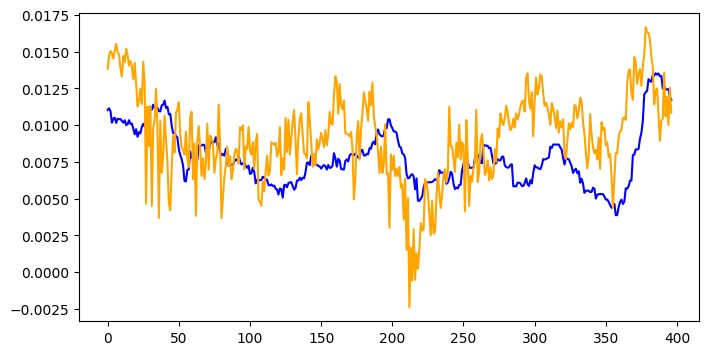

In [12]:
x = range(len(val_dataset))
labels = [val_dataset[i][1]for i in range(len(x))]

fig = plt.figure(figsize=(8, 4))
ax = fig.subplots()

ax.plot(x, labels, color='blue')
ax.plot(x, preds, color='orange')

These results look promising!  Starting to believe we are on the right track with predicting volatility.  With some tuning we may be able to improve results.

I still have doubts about using historical returns to predict future returns, however.  For now I think we should focus on predicting volatility.

In [14]:
metrics = {
    'R2': r2_score,
    'MAE': mean_absolute_error,
    'RMSE': root_mean_squared_error,
    'MSE': mean_squared_error
}
for metric, scorer in metrics.items():
    print(metric + f': {scorer(labels, np.asarray(preds))}')

R2: -1.6987707614898682
MAE: 0.0027201389893889427
RMSE: 0.003235004609450698
MSE: 1.0465254490554798e-05
